**Project:** DOOM RL WITH EXPLAINABLE AI (GRAD-CAM)

In [3]:
%%capture
# install libs

!pip install stable-baselines3[extra] gymnasium
!pip install vizdoom
!pip install moviepy

In [5]:
#@title 1. Imports

import warnings
warnings.filterwarnings('ignore')

import os
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass

# RL stuff

from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.results_plotter import load_results, ts2xy

# Visuals
from moviepy.editor import ImageSequenceClip

# Doom Integration

from vizdoom import DoomGame, ScreenFormat, ScreenResolution

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
  from scipy.ndimage.filters import sobel

  from pkg_resources import resource_stream, resource_exists

Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/refe

In [6]:
#@title 2. Configuration
import datetime

@dataclass
class Config:
  "Confiuguring..."
  SCENARIO: str = 'basic.cfg'
  RENDER_RES = ScreenResolution.RES_640X480
  SHAPE: tuple = (100,160,1)
  FRAME_STACK: int = 4

  TOTAL_TS: int = 100000
  LR: float = 2.5e-4
  N_STEPS: int = 2048
  BATCH_SIZE: int = 64
  GAMMA: float = 0.99

  # Paths

  TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

  LOG_DIR: str = f"/content/drive/MyDrive/Doom_RL/logs_{TIMESTAMP}"
  MODEL_DIR: str = f"/content/drive/MyDrive/Doom_RL/models_{TIMESTAMP}"
  VIDEO_DIR: str = "/content/drive/MyDrive/Doom_RL/videos"

  def __post_init__(self):
    os.makedirs(self.LOG_DIR, exist_ok=True)
    os.makedirs(self.MODEL_DIR, exist_ok=True)
    os.makedirs(self.VIDEO_DIR, exist_ok=True)

CONFIG = Config()

In [7]:
#@title 3. CNN

class CustomCNN(BaseFeaturesExtractor):
  def __init__(self, observation_space: spaces.Box, features_dim: int =512):
    super(CustomCNN, self).__init__(observation_space, features_dim)
    n_input_channels = observation_space.shape[0]

    # layers
    self.conv1 = nn.Conv2d(n_input_channels, 32, kernel_size=8, stride=4)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
    self.conv3 = nn.Conv2d(64,64, kernel_size=3, stride=1)
    self.flatten = nn.Flatten()

    with torch.no_grad():
      sample = torch.as_tensor(observation_space.sample()[None]).float()
      x = F.relu(self.conv1(sample))
      x = F.relu(self.conv2(x))
      x = F.relu(self.conv3(x))
      n_flatten = self.flatten(x).shape[1]

    self.linear = nn.Sequential(
        nn.Linear(n_flatten, features_dim),
        nn.ReLU()
    )

    self.gradients = None
    self.activations = None

  def activ_hook(self, grad):
    """ Hook for capturing gradients during back pass"""
    self.gradients = grad

  def forward(self, observations):

    x = F.relu(self.conv1(observations))
    x = F.relu(self.conv2(x))
    x = self.conv3(x)

    if x.requires_grad:
      h = x.register_hook(self.activ_hook)
      self.activations = x

    x = F.relu(x)
    x = self.flatten(x)
    return self.linear(x)

In [8]:
#@title 4. Enviroment

class DoomEnv(gym.Env):
  """ For trans between game pix and RL-ready tensors. """
  def __init__(self, config):
    super().__init__()
    self.game = DoomGame()
    self.game.load_config(config.SCENARIO)
    self.game.set_screen_resolution(config.RENDER_RES)
    self.game.set_screen_format(ScreenFormat.GRAY8)
    self.game.set_window_visible(False)
    self.game.init()


    self.action_space = spaces.Discrete(3)
    self.observation_space = spaces.Box(
        low=0, high=255,
        shape = config.SHAPE,
        dtype = np.uint8
    )


  def step(self, action):
    actions = np.identity(3, dtype=np.uint8)
    reward = self.game.make_action(list(actions[action]), 4)

    if reward > 0:
      reward*=10

      reward-=0.1

    if self.game.get_state():
      state = self.game.get_state().screen_buffer
      state = self.process_frame(state)
    else:
      state = np.zeros(self.observation_space.shape, dtype=np.uint8)

    done = self.game.is_episode_finished()

    return state, reward, done, False, {}


  def reset(self, seed=None, options=None):
      super().reset(seed=seed)
      self.game.new_episode()
      state = self.game.get_state().screen_buffer
      return self.process_frame(state), {}

  def process_frame(self, frame):
      """ Resize and Reshape for CNN."""
      frame = cv2.resize(frame, (160,100))
      return np.reshape(frame, (100,160,1))

  def close(self):
      self.game.close()

In [9]:
class Manager:
    def __init__(self, config: Config):
        self.config = config
        self.env = self._create_env(log_name="training_monitor")
        self.eval_env = self._create_env(log_name="eval_monitor")
        self.model = self._create_model()

    def _create_env(self, log_name="training_monitor"):
        env = DoomEnv(self.config)
        env = Monitor(env, os.path.join(self.config.LOG_DIR, "training_monitor"))
        env = DummyVecEnv([lambda: env])
        env = VecFrameStack(env, n_stack=self.config.FRAME_STACK, channels_order='last')
        return env

    def _create_model(self):
        policy_kwargs = dict(
            features_extractor_class=CustomCNN,
            features_extractor_kwargs=dict(features_dim=512)
        )

        return PPO(
            "CnnPolicy",
            self.env,
            learning_rate=self.config.LR,
            batch_size=self.config.BATCH_SIZE,
            gamma=self.config.GAMMA,
            verbose=1,
            policy_kwargs=policy_kwargs,
            tensorboard_log=self.config.LOG_DIR
        )

    def train(self):
        print(f"Starting for {self.config.TOTAL_TS} steps...")
        eval_callback = EvalCallback(
            self.eval_env,
            best_model_save_path=self.config.MODEL_DIR,
            log_path=self.config.LOG_DIR,
            eval_freq=10000,
            n_eval_episodes=5,
            deterministic=True,
            render=False
        )

        self.model.learn(
            total_timesteps=self.config.TOTAL_TS,
            callback=eval_callback
        )

        print("Training complete.")
        self.plot_results()

    def plot_results(self):
        print("Plotting learning curve...")
        x, y = ts2xy(load_results(self.config.LOG_DIR), 'timesteps')
        x = np.array(x, dtype=float)
        y = np.array(y, dtype=float)
        plt.figure(figsize=(10, 5))
        plt.plot(x, y, label="Fresh Reward", alpha=0.3)

        window = 50
        if len(y) > window:
            y_smooth = np.convolve(y, np.ones(window) / window, mode='valid')
            plt.plot(x[window - 1:], y_smooth, label=f"Smoothed (Window {window})", linewidth=2, color='red')

        plt.xlabel("Timesteps")
        plt.ylabel("Ep Reward")
        plt.title("Agent Performance")
        plt.legend()
        plt.grid(True)

        save_path = os.path.join(self.config.LOG_DIR, "learning_curve.png")
        plt.savefig(save_path)
        print(f"Plot saved to {save_path}")

    def rec_gradcam(self, filename="gradcam_gp.mp4", length = 1500):
        print(f"Recording Grad-CAM visualization to {filename} for {length} frames...")

        rec_env = self._create_env()
        frames = []
        obs = rec_env.reset()

        feat_ex = self.model.policy.features_extractor

        for i in range(length):
            raw_env = rec_env.venv.envs[0].env
            raw_screen = raw_env.game.get_state().screen_buffer


            if len(raw_screen.shape) == 2:
                raw_screen = cv2.cvtColor(raw_screen, cv2.COLOR_GRAY2RGB)

            obs_ten = torch.as_tensor(obs).to(self.model.device).float()
            obs_ten = obs_ten.permute(0, 3, 1, 2)
            obs_ten.requires_grad_()

            cnn_output = feat_ex(obs_ten)

            _, latent_vf = self.model.policy.mlp_extractor(cnn_output)
            value = self.model.policy.value_net(latent_vf)

            self.model.policy.zero_grad()
            value.backward()

            grads = feat_ex.gradients
            acts = feat_ex.activations

            pooled_grads = torch.mean(grads, dim=[0, 2, 3])

            for j in range(acts.shape[1]):
                acts[:, j, :, :] *= pooled_grads[j]

            heatmap = torch.mean(acts, dim=1).squeeze()
            heatmap = F.relu(heatmap)

            heatmap = heatmap.cpu().detach().numpy()
            heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap) + 1e-8)

            heatmap = np.uint8(255 * heatmap)
            heatmap = cv2.resize(heatmap, (raw_screen.shape[1], raw_screen.shape[0]))
            heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)


            f_img = cv2.addWeighted(raw_screen, 0.6, heatmap, 0.4, 0)
            frames.append(f_img)

            action, _ = self.model.predict(obs)
            obs, _, done, _ = rec_env.step(action)
            if done[0]:
                obs = rec_env.reset()


        rec_env.close()

        if frames:
            clip = ImageSequenceClip(frames, fps=30)
            clip.write_videofile(os.path.join(self.config.VIDEO_DIR, filename), logger=None)
        print("Video Saved")

Using cuda device
Wrapping the env in a VecTransposeImage.


  return datetime.utcnow().replace(tzinfo=utc)



Starting for 100000 steps...
Logging to /content/drive/MyDrive/Doom_RL/logs_20260111-202315/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 38.7     |
|    ep_rew_mean     | 478      |
| time/              |          |
|    fps             | 149      |
|    iterations      | 1        |
|    time_elapsed    | 13       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 42.9        |
|    ep_rew_mean          | 388         |
| time/                   |             |
|    fps                  | 135         |
|    iterations           | 2           |
|    time_elapsed         | 30          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013487549 |
|    clip_fraction        | 0.107       |
|    clip_range           | 0.2         |
|    entropy_los

  return datetime.utcnow().replace(tzinfo=utc)



Training complete.
Plotting learning curve...
Plot saved to /content/drive/MyDrive/Doom_RL/logs_20260111-202315/learning_curve.png
Recording Grad-CAM visualization to gradcam_gp.mp4 for 1500 frames...
Video Saved
Done here.


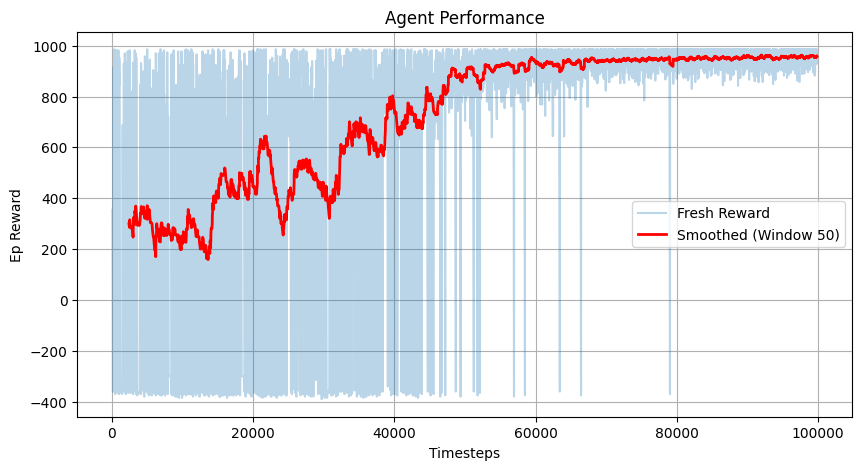

In [10]:
#@title 6. Execution

if __name__ == "__main__":
  manager = Manager(CONFIG)
  manager.train()
  manager.rec_gradcam()
  print("Done here.")

In [11]:
#@title 6. Level Up

COMP_SCENARIO = 'defend_the_center.cfg'
COMP_STEPS = 100000
LOG_DIR_COMP = "/content/drive/MyDrive/DOOM_RL/comparison_logs"
os.makedirs(LOG_DIR_COMP, exist_ok=True)


class CompDoomEnv(gym.Env):
    def __init__(self, scenario_name):
        super().__init__()
        self.game = DoomGame()


        import vizdoom.scenarios
        vizdoom_path = os.path.dirname(vizdoom.__file__)
        scenarios_path = os.path.join(vizdoom_path, "scenarios")
        config_path = os.path.join(scenarios_path, scenario_name)
        try:
            self.game.load_config(config_path)
        except Exception as e:
          print(f"Error loading config at {config_path}: {e}")
          self.game.load_config(scenario_name)

        self.game.set_screen_resolution(ScreenResolution.RES_320X240)
        self.game.set_screen_format(ScreenFormat.GRAY8)
        self.game.set_window_visible(False)
        self.game.init()

        self.n_actions = self.game.get_available_buttons_size()
        self.action_space = spaces.Discrete(self.n_actions)
        self.observation_space = spaces.Box(
            low=0, high=255,
            shape=(100, 160, 1),
            dtype=np.uint8
        )

    def step(self, action):

        actions = np.identity(self.n_actions, dtype=np.uint8)
        reward = self.game.make_action(list(actions[action]), 4) / 10.0

        if self.game.get_state():
            state = self.game.get_state().screen_buffer
            state = cv2.resize(state, (160, 100))
            state = np.reshape(state, (100, 160, 1))
        else:

            state = np.zeros(self.observation_space.shape, dtype=np.uint8)

        done = self.game.is_episode_finished()

        return state, reward, done, False, {}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.game.new_episode()
        state = self.game.get_state().screen_buffer
        state = cv2.resize(state, (160, 100))
        return np.reshape(state, (100, 160, 1)), {}

    def close(self):
        self.game.close()


 ~~~ Training My_CustomCNN on defend_the_center.cfg ~~~
Using cuda device
Logging to /content/drive/MyDrive/DOOM_RL/comparison_logs/PPO_5
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 84.3     |
|    ep_rew_mean     | 0.0375   |
| time/              |          |
|    fps             | 275      |
|    iterations      | 1        |
|    time_elapsed    | 7        |
|    total_timesteps | 2048     |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 87.1       |
|    ep_rew_mean          | 0.0587     |
| time/                   |            |
|    fps                  | 236        |
|    iterations           | 2          |
|    time_elapsed         | 17         |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.00933688 |
|    clip_fraction        | 0.0395     |
|    clip_range           | 0

  return datetime.utcnow().replace(tzinfo=utc)



 Finished Default_NatureCNN
Generating comparison chart...


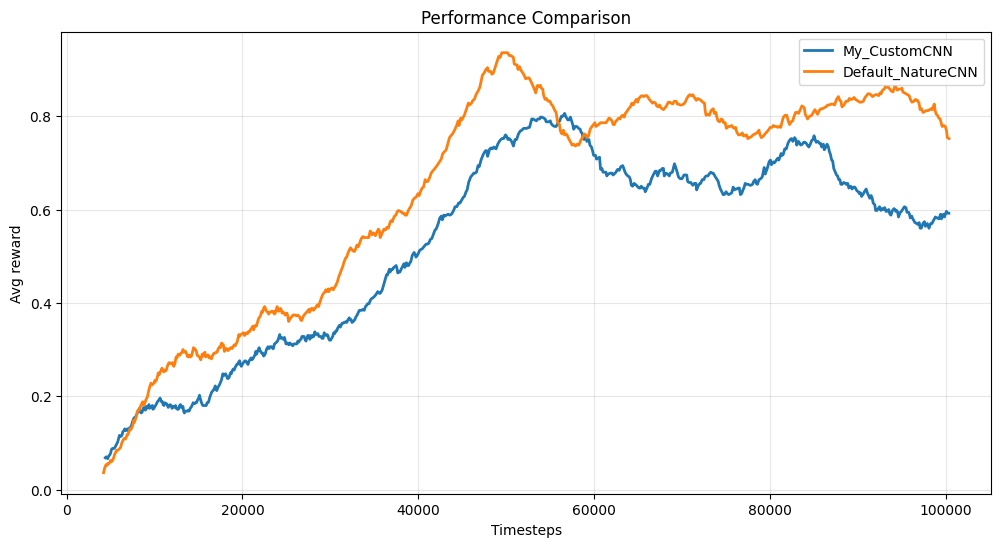

Chart saved to /content/drive/MyDrive/DOOM_RL/comparison_logs/comparison_chart.png


In [12]:
from stable_baselines3.common.vec_env import VecTransposeImage
import os

def cc_env(rank, name):
    def _init():
        env = CompDoomEnv(COMP_SCENARIO)
        log_sub_dir = os.path.join(LOG_DIR_COMP, name)
        os.makedirs(log_sub_dir, exist_ok=True)
        env = Monitor(env, os.path.join(log_sub_dir, name))
        return env
    return _init

models_to_test = [
    {
        "name": "My_CustomCNN",
        "policy_kwargs": dict(
            features_extractor_class=CustomCNN,
            features_extractor_kwargs=dict(features_dim=512)
        )
    },
    {
        "name": "Default_NatureCNN",
        "policy_kwargs": {}
    }
]

                   # Training Loop

for model_cfg in models_to_test:
    name = model_cfg['name']
    print(f"\n ~~~ Training {name} on {COMP_SCENARIO} ~~~")

    env = DummyVecEnv([cc_env(0, name)])
    env = VecFrameStack(env, 4, channels_order='last')
    env = VecTransposeImage(env)

    model = PPO(
        "CnnPolicy",
        env,
        verbose=1,
        learning_rate=2.5e-4,
        n_steps=2048,
        batch_size=64,
        policy_kwargs=model_cfg['policy_kwargs'],
        tensorboard_log=LOG_DIR_COMP
    )

    model.learn(total_timesteps=COMP_STEPS)
    model.save(os.path.join(LOG_DIR_COMP, name))
    env.close()
    print(f" Finished {name}")

                          # Plotting Results

print(f"Generating comparison chart...")
plt.figure(figsize=(12, 6))

for model_cfg in models_to_test:
    name = model_cfg['name']
    log_path = os.path.join(LOG_DIR_COMP, name)

    try:
        x, y = ts2xy(load_results(log_path), 'timesteps')
        window = 50

        if len(y) > window:
            y_smooth = np.convolve(y, np.ones(window)/window, mode='valid')
            x_trim = x[len(x) - len(y_smooth):]
            plt.plot(x_trim, y_smooth, label=name, linewidth=2)
        else:
            plt.plot(x, y, label=name + " (Raw)", alpha=0.6)
    except Exception as e:
        print(f"Could not plot {name}: {e}")

plt.title("Performance Comparison")
plt.xlabel("Timesteps")
plt.ylabel("Avg reward")
plt.legend()
plt.grid(True, alpha=0.3)


chart_path = os.path.join(LOG_DIR_COMP, 'comparison_chart.png')
plt.savefig(chart_path)
plt.show()

print(f"Chart saved to {chart_path}")